# 第19章: Store Demand時系列予測 - GBDT×時系列の完全ガイド ⏰

## 📋 この章で学ぶこと

この章を終えると、以下ができるようになります：

- [ ] 時系列データの3成分（トレンド、季節性、残差）を分解・説明できる
- [ ] ACF/PACFグラフから有意なラグを特定できる
- [ ] Lag特徴量とRolling特徴量を適切に作成できる
- [ ] 時系列データを正しく分割（Temporal Split）できる
- [ ] GBDTで時系列予測モデルを構築できる
- [ ] SMAPEを使って予測精度を評価できる

## 🎯 前提知識

この章を学ぶには以下の知識が必要です：

- ✅ Notebook 13-14（GBDTの基礎）
- ✅ Notebook 18（回帰問題の基礎）
- ✅ 基本的な時系列の概念（トレンド、季節性）

⏱️ **推定学習時間**: 120-150分
📊 **難易度**: ★★★★☆（上級）
🎓 **カテゴリ**: 実践・時系列予測

---

## 🎯 目標

- **SMAPE**: < 15%
- **Kaggle Store Item Demand**: Top 25%

---

## 📚 時系列予測の基礎理論

### 🤔 なぜ時系列予測は特別なのか？

通常の機械学習と時系列予測の最大の違いは**時間的な順序**があることです。

**通常の機械学習:**
```
データ: [サンプル1, サンプル2, サンプル3, ...]
        順番は関係ない → シャッフルしてOK
```

**時系列予測:**
```
データ: [1月, 2月, 3月, 4月, ...]
        順番に意味がある → シャッフルNG！
```

### ⚠️ 時系列でやってはいけないこと

| やってはいけないこと | 理由 | 正しいアプローチ |
|----------------------|------|------------------|
| データのシャッフル | 時間の順序が壊れる | 時間順で分割 |
| ランダムなCV | 未来データで学習してしまう | Walk-forward CV |
| 未来の情報を使う | データリーク | Lag特徴量のみ使用 |

### 📊 時系列の3成分

すべての時系列は以下の3成分に分解できます：

```
時系列 = トレンド + 季節性 + 残差

        トレンド（長期傾向）:
        ────────────────────────→
                              ↗

        季節性（周期的パターン）:
        ∿∿∿∿∿∿∿∿∿∿∿∿∿∿∿∿∿∿∿∿∿∿∿

        残差（ランダムな変動）:
        ∾∾∾∾∾∾∾∾∾∾∾∾∾∾∾∾∾∾∾∾∾∾∾
```

**各成分の例（小売売上）:**
- **トレンド**: 経済成長による長期的な売上増加
- **季節性**: 12月のホリデーシーズンの売上急増、週末の売上増
- **残差**: 天気、イベント、ニュースによる予測不能な変動

---

In [1]:
# 基本ライブラリ
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
from datetime import datetime, timedelta

# 時系列分析
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 機械学習
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error

# GBDT
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor

# 設定
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('tab10')
pd.set_option('display.max_columns', None)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ セットアップ完了")

# 日本語フォント設定
import matplotlib.font_manager as fm

def setup_japanese_font():
    """日本語フォントを設定する"""
    japanese_fonts = [
        'Hiragino Sans', 'Hiragino Maru Gothic Pro', 'AppleGothic',  # macOS
        'Yu Gothic', 'MS Gothic',  # Windows
        'Noto Sans CJK JP', 'IPAexGothic', 'TakaoPGothic',  # Linux
    ]
    available_fonts = set(f.name for f in fm.fontManager.ttflist)
    for font in japanese_fonts:
        if font in available_fonts:
            plt.rcParams['font.family'] = font
            plt.rcParams['axes.unicode_minus'] = False
            return font
    return None

font_used = setup_japanese_font()
if font_used:
    print(f"Japanese font: {font_used}")


C:\Users\yuzup\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


✅ セットアップ完了
Japanese font: Yu Gothic


## 📊 1. データ読み込みとEDA

In [2]:
# データディレクトリ
data_dir = Path('../data/store_demand')
data_dir.mkdir(parents=True, exist_ok=True)

try:
    train = pd.read_csv(data_dir / 'train.csv', parse_dates=['date'])
    test = pd.read_csv(data_dir / 'test.csv', parse_dates=['date'])
    print("✅ データ読み込み成功")
except FileNotFoundError:
    print("⚠️ デモ用の時系列データを生成")
    # デモ用データ生成
    dates = pd.date_range(start='2013-01-01', end='2017-12-31', freq='D')
    n_stores = 10
    n_items = 50
    
    data_list = []
    for store in range(1, n_stores + 1):
        for item in range(1, n_items + 1):
            # トレンド + 季節性 + ノイズ
            trend = np.linspace(10, 50, len(dates))
            seasonality = 20 * np.sin(np.arange(len(dates)) * 2 * np.pi / 365.25)
            weekly = 10 * np.sin(np.arange(len(dates)) * 2 * np.pi / 7)
            noise = np.random.normal(0, 5, len(dates))
            sales = np.maximum(0, trend + seasonality + weekly + noise + store * 2 + item)
            
            df_temp = pd.DataFrame({
                'date': dates,
                'store': store,
                'item': item,
                'sales': sales
            })
            data_list.append(df_temp)
    
    train = pd.concat(data_list, ignore_index=True)
    # テストデータ（次の3ヶ月）
    test_dates = pd.date_range(start='2018-01-01', end='2018-03-31', freq='D')
    test = pd.DataFrame({
        'date': np.tile(test_dates, n_stores * n_items),
        'store': np.repeat(np.arange(1, n_stores + 1), len(test_dates) * n_items),
        'item': np.tile(np.repeat(np.arange(1, n_items + 1), len(test_dates)), n_stores)
    })

print(f"\nTrain shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"\nDate range: {train['date'].min()} to {train['date'].max()}")

# 最初の数行
display(train.head(10))

⚠️ デモ用の時系列データを生成

Train shape: (913000, 4)
Test shape: (45000, 3)

Date range: 2013-01-01 00:00:00 to 2017-12-31 00:00:00


,date,store,item,sales
0,2013-01-01,1,1,15.483571
1,2013-01-02,1,1,20.492943
2,2013-01-03,1,1,26.719519
3,2013-01-04,1,1,26.051427
4,2013-01-05,1,1,8.953175
5,2013-01-06,1,1,3.907747
6,2013-01-07,1,1,15.269884
7,2013-01-08,1,1,19.393122
8,2013-01-09,1,1,21.389993
9,2013-01-10,1,1,28.743421


### 1.1 時系列の可視化

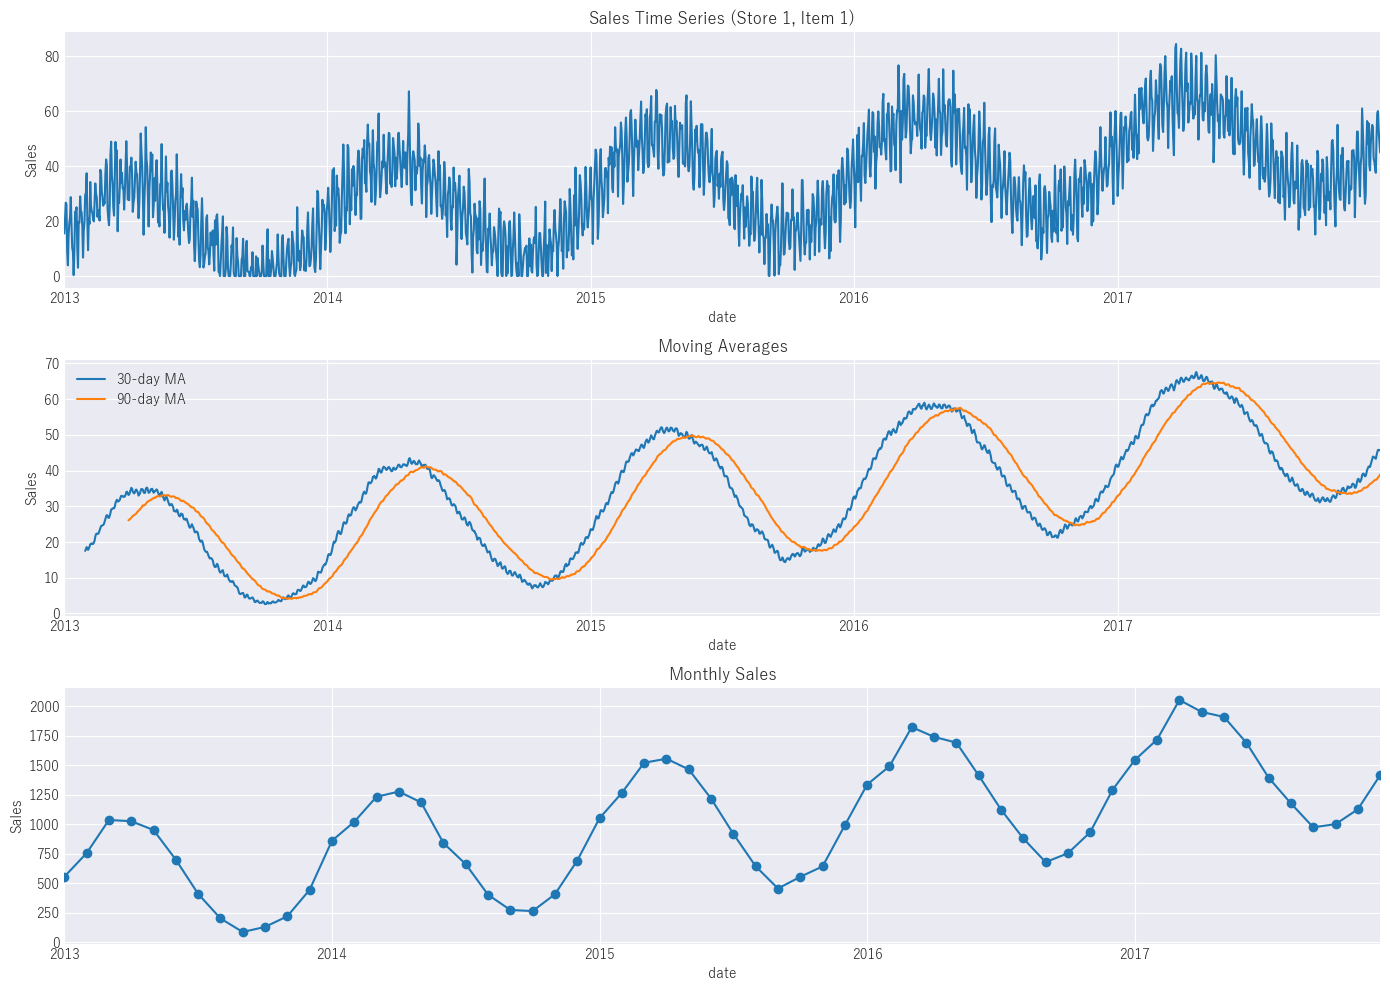

In [3]:
# 1つの店舗・商品の時系列を可視化
sample = train[(train['store'] == 1) & (train['item'] == 1)].copy()
sample = sample.set_index('date')['sales']

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# 1. 元の時系列
sample.plot(ax=axes[0])
axes[0].set_title('Sales Time Series (Store 1, Item 1)')
axes[0].set_ylabel('Sales')

# 2. 移動平均
sample.rolling(window=30).mean().plot(ax=axes[1], label='30-day MA')
sample.rolling(window=90).mean().plot(ax=axes[1], label='90-day MA')
axes[1].set_title('Moving Averages')
axes[1].set_ylabel('Sales')
axes[1].legend()

# 3. 月次集計
monthly = sample.resample('M').sum()
monthly.plot(ax=axes[2], marker='o')
axes[2].set_title('Monthly Sales')
axes[2].set_ylabel('Sales')

plt.tight_layout()
plt.show()

### 🤔 なぜ時系列は「分解」できるのか？

時系列データは、**異なる周波数の信号の重ね合わせ**と考えることができます。

1. **トレンド（低周波）**: ゆっくりと変化する長期的な動き
2. **季節性（特定周波）**: 一定の周期（1週間、1年など）で繰り返す動き
3. **残差（高周波）**: ランダムなノイズ

**分解の仕組み（加法モデルの例）:**
$$Y(t) = \text{Trend}(t) + \text{Seasonality}(t) + \text{Residual}(t)$$

1. **移動平均**をとることで、細かい変動（季節性とノイズ）を平滑化し、**トレンド**を取り出します。
2. 元のデータからトレンドを引き算すると、「季節性＋ノイズ」が残ります。
3. この「季節性＋ノイズ」を周期ごとに平均する（例：すべての月曜日の平均をとる）ことで、ランダムな**ノイズ**が相殺され、純粋な**季節性**パターンが浮かび上がります。
4. 最後に残ったものが**残差**です。

このように、**「周期性の有無」と「変化の速度」の違い**を利用して、データを3つの成分に分離することが可能です。

### 1.2 季節性分解

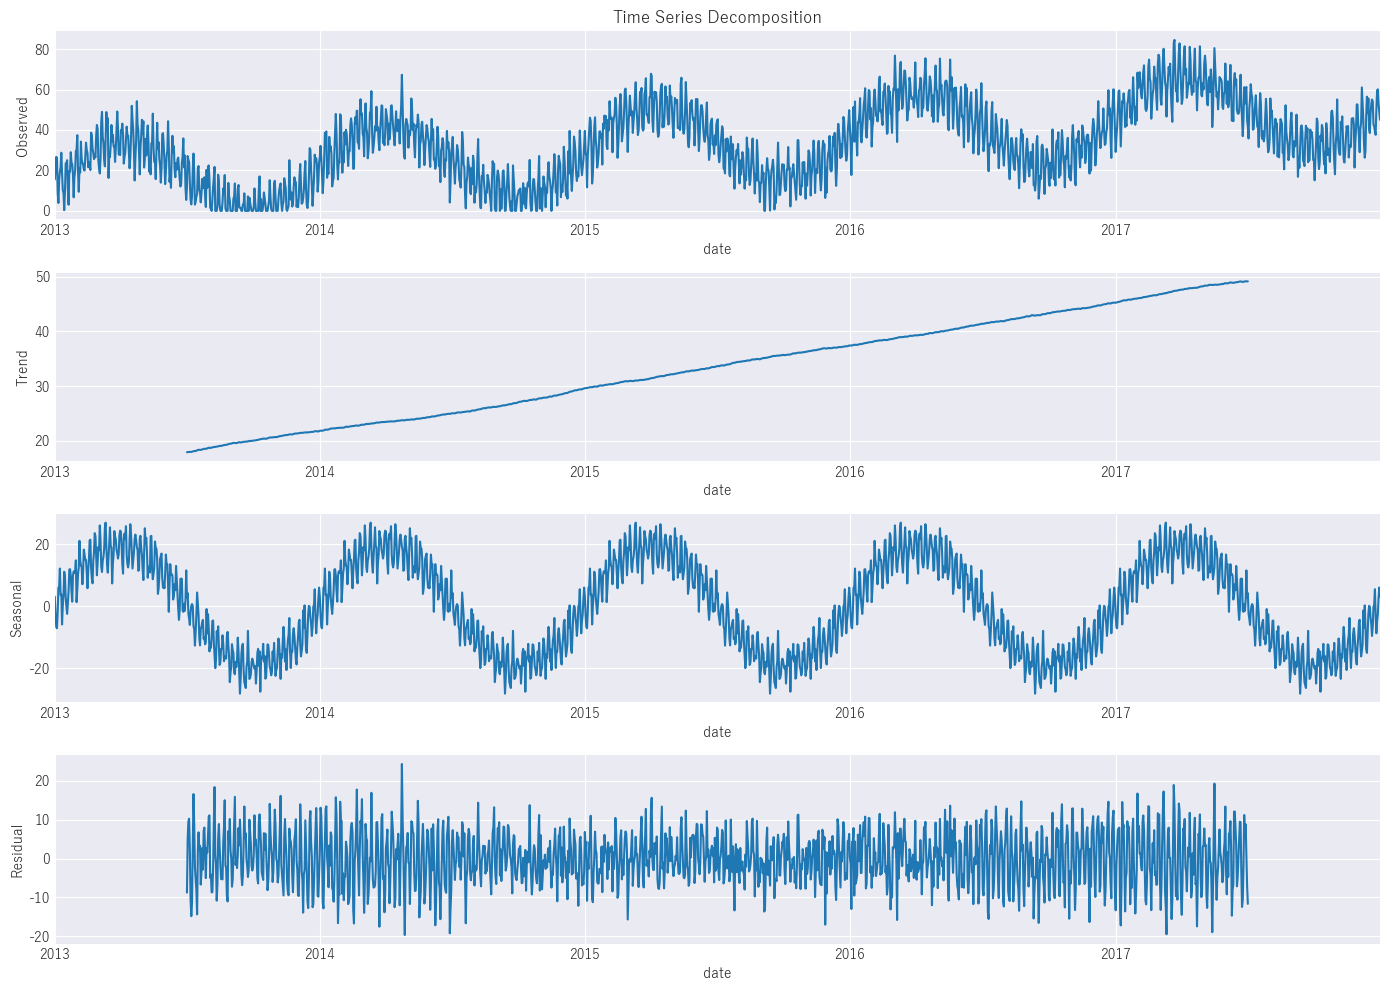

In [4]:
# 季節性分解（加法モデル）
decomposition = seasonal_decompose(sample, model='additive', period=365)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))

decomposition.observed.plot(ax=axes[0])
axes[0].set_ylabel('Observed')
axes[0].set_title('Time Series Decomposition')

decomposition.trend.plot(ax=axes[1])
axes[1].set_ylabel('Trend')

decomposition.seasonal.plot(ax=axes[2])
axes[2].set_ylabel('Seasonal')

decomposition.resid.plot(ax=axes[3])
axes[3].set_ylabel('Residual')

plt.tight_layout()
plt.show()

### 1.3 自己相関分析（ACF/PACF）

### 🤔 自己相関とは何か？

**自己相関（Autocorrelation）** は、時系列データと自身のラグ（過去の値）との相関です。

$$\text{ACF}(k) = \frac{\text{Cov}(y_t, y_{t-k})}{\text{Var}(y_t)}$$

**なぜ自己相関が重要か？**
- 有意なラグ（例：7日前、30日前）を特定できる
- 季節性のパターンを発見できる
- どのLag特徴量を作るべきかの指針になる

### 📊 ACF vs PACF

| 指標 | 説明 | 用途 |
|------|------|------|
| **ACF** | 間接的な影響も含む自己相関 | 移動平均(MA)パラメータの特定 |
| **PACF** | 直接的な影響のみの自己相関 | 自己回帰(AR)パラメータの特定 |

**グラフの読み方:**
```
ACF/PACFグラフ:
  1.0 |
      |━━━  ← 青い点線を超えると統計的に有意
  0.5 |    ━━━
      |        ━━━
  0.0 |------------━━━----------
      |                ━━━
 -0.5 |
      +---------------------------
         0   7  14  21  28  ← ラグ（日数）
```

**典型的なパターン:**
- **ラグ7で有意**: 週次の季節性
- **ラグ30で有意**: 月次の季節性
- **ラグ365で有意**: 年次の季節性

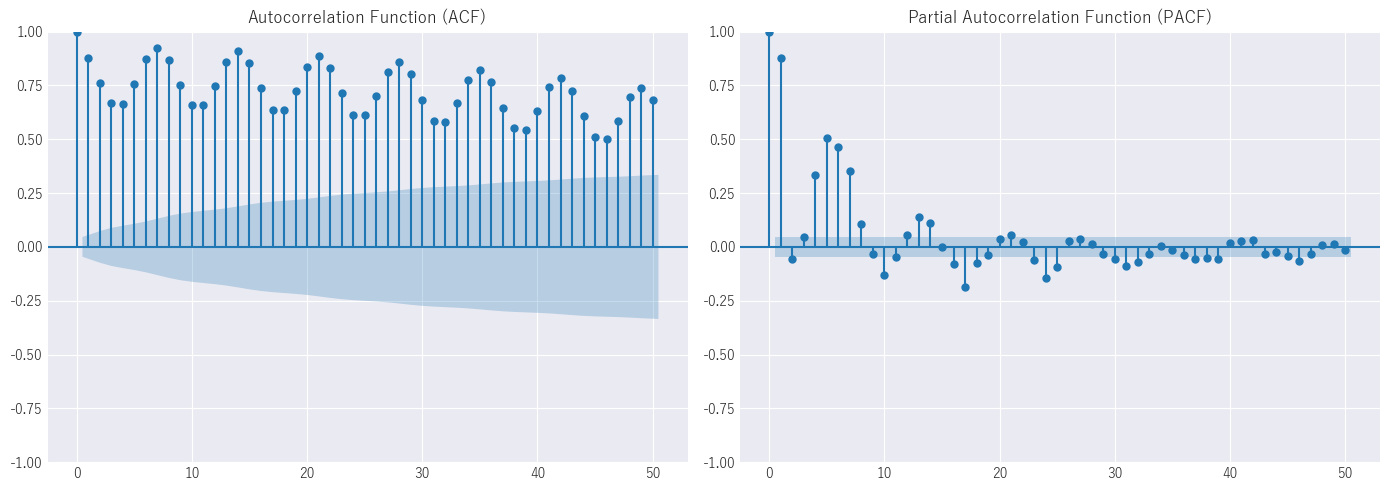


📊 ACF/PACFから、有意なラグ（lag）を特定できます
   - 7日ラグ: 週次パターン
   - 30日ラグ: 月次パターン
   - 365日ラグ: 年次パターン


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ACF
plot_acf(sample.dropna(), lags=50, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)')

# PACF
plot_pacf(sample.dropna(), lags=50, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF)')

plt.tight_layout()
plt.show()

print("\n📊 ACF/PACFから、有意なラグ（lag）を特定できます")
print("   - 7日ラグ: 週次パターン")
print("   - 30日ラグ: 月次パターン")
print("   - 365日ラグ: 年次パターン")

## 🔨 2. 時系列特徴量エンジニアリング ⭐⭐⭐

### 🤔 なぜ時系列特有の特徴量が必要なのか？

GBDTは強力なアルゴリズムですが、**時間の概念を理解しません**。
日付をそのまま与えても、「2024-01-15」が冬であること、月曜日であること、
前日の売上と関連があることを自動的に学習できません。

**特徴量エンジニアリングで伝えるべき情報:**

| 情報タイプ | 例 | 特徴量 |
|------------|-----|--------|
| 周期性 | 曜日、月、季節 | dayofweek, month, quarter |
| 過去の値 | 昨日の売上、先週の売上 | lag_1, lag_7 |
| 過去の傾向 | 直近7日の平均 | rolling_mean_7 |
| イベント | 祝日、セール | is_holiday, is_sale |

### 📊 周期性のエンコーディング

**問題: 月（1-12）をそのまま数値で使うと...**
```
1月 = 1, 12月 = 12
→ モデルは「12月は1月の12倍重要」と誤解する可能性
→ 1月と12月が「近い」ことを理解できない（実際は連続）
```

**解決策: 正弦・余弦エンコーディング**
```python
month_sin = sin(2π × month / 12)
month_cos = cos(2π × month / 12)
```

```
            sin(month)    cos(month)
1月 (冬)  :    0.5          0.87
6月 (夏)  :    0.0         -1.0
12月 (冬) :   -0.5          0.87  ← 1月と近い値！
```

この変換により、12月と1月が「近い」ことをモデルが理解できます。

In [6]:
def create_time_series_features(df):
    """
    時系列特徴量の作成
    """
    df = df.copy()
    
    # 日付特徴量
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day'] = df['date'].dt.day
    df['dayofweek'] = df['date'].dt.dayofweek
    df['dayofyear'] = df['date'].dt.dayofyear
    df['weekofyear'] = df['date'].dt.isocalendar().week
    df['quarter'] = df['date'].dt.quarter
    
    # 週末フラグ
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
    
    # 月初・月末フラグ
    df['is_month_start'] = df['date'].dt.is_month_start.astype(int)
    df['is_month_end'] = df['date'].dt.is_month_end.astype(int)
    
    # 周期性の正弦・余弦エンコーディング
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['day_sin'] = np.sin(2 * np.pi * df['day'] / 31)
    df['day_cos'] = np.cos(2 * np.pi * df['day'] / 31)
    df['dayofweek_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['dayofweek_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)
    
    print(f"✅ 時系列特徴量作成完了: {df.shape[1]} 特徴量")
    return df

# 特徴量作成
train = create_time_series_features(train)
test = create_time_series_features(test)

✅ 時系列特徴量作成完了: 20 特徴量
✅ 時系列特徴量作成完了: 19 特徴量


### 2.1 Lag Features（ラグ特徴量） ⭐⭐⭐

### 🤔 なぜラグ特徴量が最も重要なのか？

時系列予測で最も予測力の高い情報は、**過去の値そのもの**です。

**直感的な例:**
「明日の売上はいくらか？」という問いに対して...
- 「今日は50個売れた」→ 「おそらく明日も50個前後」
- 「先週の同じ曜日は60個売れた」→ 「週次パターンを考慮すると60個前後」

### 📊 どのラグを使うべきか？

| ラグ | 意味 | 使用場面 |
|------|------|----------|
| lag_1 | 1日前 | 短期トレンド |
| lag_7 | 1週間前（同じ曜日） | 週次パターン |
| lag_14 | 2週間前 | 週次パターンの補強 |
| lag_28 | 4週間前 | 月次パターン |
| lag_30 | 1ヶ月前 | 月次パターン |
| lag_365 | 1年前 | 年次季節性 |

### ⚠️ ラグ特徴量の注意点

**問題1: 予測時にラグ値が存在しない**
```
訓練: 1月1日〜12月31日のデータで学習
予測: 1月1日の売上を予測したい
     → lag_1（12月31日の売上）は訓練データに存在
     → OK！

予測: 1月2日の売上を予測したい
     → lag_1（1月1日の売上）はまだ予測値！
     → どうする？
```

**解決策:**
1. **再帰的予測**: 予測値を次のlag_1として使用（誤差が蓄積）
2. **直接予測**: lag_1を使わず、lag_7以上のみ使用（精度低下）
3. **ハイブリッド**: 短期はlag_1使用、長期はlag_7以上

**問題2: データリーク**
```python
# ❌ 間違い: 未来の情報を使っている
df['future_leak'] = df['sales'].shift(-1)  # 1日後の売上

# ✅ 正しい: 過去の情報のみ
df['lag_1'] = df['sales'].shift(1)  # 1日前の売上
```

In [7]:
def create_lag_features(df, lags=[1, 7, 14, 28, 30, 60, 90]):
    """
    Lag features（過去の売上）の作成
    """
    df = df.copy()
    df = df.sort_values(['store', 'item', 'date'])
    
    if 'sales' in df.columns:
        for lag in lags:
            df[f'sales_lag_{lag}'] = df.groupby(['store', 'item'])['sales'].shift(lag)
    
    print(f"✅ Lag特徴量作成: {len(lags)} lags")
    return df

# Train データにLag特徴量を追加
train = create_lag_features(train, lags=[1, 7, 14, 28, 30, 60, 90])

✅ Lag特徴量作成: 7 lags


### 2.2 Rolling Window Statistics（移動窓統計量） ⭐⭐⭐

### 🤔 なぜ移動統計量が有効なのか？

単一のラグ値は**ノイズに弱い**という問題があります。

**例: 1日前の売上だけに頼ると...**
```
通常の日:     50, 52, 48, 51, 49  → 安定
異常な日:     50, 52, 10, 51, 49  → 10は外れ値（停電など）

lag_1 = 10 を使うと、翌日の予測が大きく外れる！
```

**解決策: 移動平均を使う**
```
rolling_mean_7 = (50 + 52 + 10 + 51 + 49 + ...) / 7 ≈ 45
→ 外れ値の影響が薄まる
```

### 📊 主要な移動統計量

| 統計量 | 計算方法 | 捕捉する情報 |
|--------|----------|--------------|
| **rolling_mean** | 過去N日の平均 | 平均的な水準 |
| **rolling_std** | 過去N日の標準偏差 | 変動の大きさ |
| **rolling_min** | 過去N日の最小値 | 下限値 |
| **rolling_max** | 過去N日の最大値 | 上限値 |
| **rolling_median** | 過去N日の中央値 | 外れ値に頑健な水準 |

### 📊 ウィンドウサイズの選び方

```
短い窓（7日）:
  - 直近のトレンドに敏感
  - ノイズの影響を受けやすい
  - 急激な変化に追従

長い窓（30日）:
  - 長期トレンドを捕捉
  - ノイズに頑健
  - 変化への反応が遅い
```

**実践的なアドバイス:**
- 複数のウィンドウサイズを試す（7, 14, 30日など）
- 特徴量重要度を見て、不要なものを削除
- ビジネスの周期に合わせる（週単位なら7の倍数）

In [8]:
def create_rolling_features(df, windows=[7, 14, 30, 60, 90]):
    """
    Rolling window statistics
    """
    df = df.copy()
    df = df.sort_values(['store', 'item', 'date'])
    
    if 'sales' in df.columns:
        for window in windows:
            # Rolling mean
            df[f'sales_rolling_mean_{window}'] = (
                df.groupby(['store', 'item'])['sales']
                .transform(lambda x: x.rolling(window=window, min_periods=1).mean())
            )
            
            # Rolling std
            df[f'sales_rolling_std_{window}'] = (
                df.groupby(['store', 'item'])['sales']
                .transform(lambda x: x.rolling(window=window, min_periods=1).std())
            )
            
            # Rolling max/min
            df[f'sales_rolling_max_{window}'] = (
                df.groupby(['store', 'item'])['sales']
                .transform(lambda x: x.rolling(window=window, min_periods=1).max())
            )
            df[f'sales_rolling_min_{window}'] = (
                df.groupby(['store', 'item'])['sales']
                .transform(lambda x: x.rolling(window=window, min_periods=1).min())
            )
    
    print(f"✅ Rolling特徴量作成: {len(windows)} windows")
    return df

# Rolling特徴量追加
train = create_rolling_features(train, windows=[7, 14, 30])

✅ Rolling特徴量作成: 3 windows


## 🎯 3. データ準備

### ⚠️ 重要: 時系列データではシャッフルしない！

### 🤔 なぜシャッフルしてはいけないのか？

**通常の機械学習:**
```
データ: [A, B, C, D, E]
シャッフル後: [C, A, E, B, D]
→ 各サンプルは独立なので問題なし
```

**時系列:**
```
データ: [1月, 2月, 3月, 4月, 5月]
シャッフル後: [3月, 1月, 5月, 2月, 4月]
→ 3月のデータで学習 → 1月を予測？ 
→ 未来で学習して過去を予測 = データリーク！
```

**正しいアプローチ:**
```
訓練: [1月, 2月, 3月, 4月] → 時間順に並んだまま
検証: [5月]               → 訓練より後の期間

モデルは「過去を見て未来を予測」という
現実の設定で評価される
```

In [9]:
# 特徴量とターゲットの分離
feature_cols = [col for col in train.columns if col not in ['date', 'sales']]
X = train[feature_cols]
y = train['sales']

# 欠損値補完（Lag特徴量で発生）
X = X.fillna(0)

print(f"✅ データ準備完了")
print(f"   特徴量数: {X.shape[1]}")
print(f"   サンプル数: {X.shape[0]}")
print(f"\n特徴量リスト（抜粋）:")
for i, col in enumerate(X.columns[:20], 1):
    print(f"{i:2d}. {col}")

✅ データ準備完了
   特徴量数: 37
   サンプル数: 913000

特徴量リスト（抜粋）:
 1. store
 2. item
 3. year
 4. month
 5. day
 6. dayofweek
 7. dayofyear
 8. weekofyear
 9. quarter
10. is_weekend
11. is_month_start
12. is_month_end
13. month_sin
14. month_cos
15. day_sin
16. day_cos
17. dayofweek_sin
18. dayofweek_cos
19. sales_lag_1
20. sales_lag_7


### 3.1 時系列分割（Temporal Split）

### 📊 時系列CV（Walk-Forward Validation）

通常のK-Foldとは異なり、常に**時間的に後のデータで検証**します。

```
Walk-Forward CV の概念図:

  データ: [==============================]
          2013      2015      2017

  Fold 1: [訓練====]  [検証]
          2013-2014   2015

  Fold 2: [訓練========]  [検証]
          2013-2015       2016

  Fold 3: [訓練============]  [検証]
          2013-2016           2017

  → 訓練データは常に検証データより前の期間
  → 現実の予測シナリオを再現
```

### ⚠️ 時系列分割の注意点

**Gapの設定:**
```python
# 予測期間が30日先の場合
# 訓練の最後と検証の最初に30日のギャップを設ける

訓練: [1月1日 〜 11月30日]
gap:  [12月1日 〜 12月30日]  ← 使わない
検証: [12月31日 〜 1月30日]

なぜ？ 実際の予測時も、直近30日は使えないから
```

In [10]:
# 時系列順でソート
train_sorted = train.sort_values('date').reset_index(drop=True)
X_sorted = train_sorted[feature_cols].fillna(0)
y_sorted = train_sorted['sales']

# 最後の3ヶ月をバリデーション
split_date = train_sorted['date'].max() - pd.Timedelta(days=90)
train_mask = train_sorted['date'] < split_date
val_mask = train_sorted['date'] >= split_date

X_train = X_sorted[train_mask]
y_train = y_sorted[train_mask]
X_val = X_sorted[val_mask]
y_val = y_sorted[val_mask]

print(f"\n📊 データ分割:")
print(f"   Train: {len(X_train)} samples")
print(f"   Validation: {len(X_val)} samples")
print(f"   Split date: {split_date}")


📊 データ分割:
   Train: 867500 samples
   Validation: 45500 samples
   Split date: 2017-10-02 00:00:00


## 🚀 4. GBDT Time Series Modeling

### 4.1 SMAPE評価関数

### 🤔 なぜSMAPEを使うのか？

**MAPE (Mean Absolute Percentage Error)** の問題:

$$\text{MAPE} = \frac{1}{n}\sum_{i=1}^{n}\left|\frac{y_i - \hat{y}_i}{y_i}\right| \times 100$$

```
実測: 10, 予測: 5  → |10-5|/10 = 50%
実測: 5,  予測: 10 → |5-10|/5  = 100%  ← 非対称！
```

MAPEは過小予測と過大予測を非対称に扱います。

**SMAPE (Symmetric MAPE)** はこの問題を解決:

$$\text{SMAPE} = \frac{1}{n}\sum_{i=1}^{n}\frac{|y_i - \hat{y}_i|}{(|y_i| + |\hat{y}_i|)/2} \times 100$$

```
実測: 10, 予測: 5  → |10-5|/((10+5)/2) = 66.7%
実測: 5,  予測: 10 → |5-10|/((5+10)/2) = 66.7%  ← 対称！
```

### 📊 評価指標の比較

| 指標 | 特徴 | 使用場面 |
|------|------|----------|
| **RMSE** | 大きな誤差を重く罰する | 外れ値が問題の場合 |
| **MAE** | すべての誤差を均等に扱う | 外れ値に頑健 |
| **MAPE** | 相対誤差、非対称 | 正の値のみ、過小予測を重視 |
| **SMAPE** | 相対誤差、対称 | 正の値のみ、バランス重視 |
| **RMSLE** | 相対誤差（対数）、対称 | 価格など広いスケール |

In [11]:
def smape(y_true, y_pred):
    """
    Symmetric Mean Absolute Percentage Error
    """
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    diff = np.abs(y_true - y_pred) / denominator
    diff[denominator == 0] = 0.0
    return 100 * np.mean(diff)

print("✅ SMAPE評価関数定義完了")

✅ SMAPE評価関数定義完了


### 4.2 LightGBM

In [12]:
# LightGBMパラメータ
params_lgb = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'n_estimators': 1000,
    'max_depth': 6,
    'min_child_samples': 20,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': RANDOM_STATE,
    'verbose': -1
}

model_lgb = lgb.LGBMRegressor(**params_lgb)
model_lgb.fit(X_train, y_train,
             eval_set=[(X_val, y_val)],
             callbacks=[lgb.early_stopping(50, verbose=False)])

# 予測
preds_lgb = model_lgb.predict(X_val)
preds_lgb = np.maximum(0, preds_lgb)  # 負の値を0にクリップ

# スコア
smape_lgb = smape(y_val, preds_lgb)
rmse_lgb = np.sqrt(mean_squared_error(y_val, preds_lgb))
mae_lgb = mean_absolute_error(y_val, preds_lgb)

print(f"\n📊 LightGBM Results:")
print(f"   SMAPE: {smape_lgb:.2f}%")
print(f"   RMSE:  {rmse_lgb:.2f}")
print(f"   MAE:   {mae_lgb:.2f}")


📊 LightGBM Results:
   SMAPE: 4.70%
   RMSE:  4.01
   MAE:   3.16


### 4.3 XGBoost

In [13]:
# XGBoostパラメータ
params_xgb = {
    'objective': 'reg:squarederror',
    'max_depth': 6,
    'learning_rate': 0.05,
    'n_estimators': 1000,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': RANDOM_STATE
}

model_xgb = xgb.XGBRegressor(
    early_stopping_rounds=50,
   **params_xgb)
model_xgb.fit(X_train, y_train,
             eval_set=[(X_val, y_val)],
    verbose=False)

preds_xgb = np.maximum(0, model_xgb.predict(X_val))
smape_xgb = smape(y_val, preds_xgb)

print(f"\n📊 XGBoost SMAPE: {smape_xgb:.2f}%")


📊 XGBoost SMAPE: 4.65%


### 4.4 CatBoost

In [14]:
# CatBoostパラメータ
params_cat = {
    'loss_function': 'RMSE',
    'depth': 6,
    'learning_rate': 0.05,
    'iterations': 1000,
    'random_state': RANDOM_STATE,
    'verbose': False
}

model_cat = CatBoostRegressor(**params_cat)
model_cat.fit(X_train, y_train,
             eval_set=(X_val, y_val), verbose=False)

preds_cat = np.maximum(0, model_cat.predict(X_val))
smape_cat = smape(y_val, preds_cat)

print(f"\n📊 CatBoost SMAPE: {smape_cat:.2f}%")


📊 CatBoost SMAPE: 4.80%


## 🎭 5. アンサンブル

In [15]:
# 重み付きアンサンブル
weights = [0.4, 0.3, 0.3]
ensemble_preds = (weights[0] * preds_lgb + 
                  weights[1] * preds_xgb + 
                  weights[2] * preds_cat)

smape_ensemble = smape(y_val, ensemble_preds)

print(f"\n🎯 アンサンブル結果:")
print(f"   LightGBM: {smape_lgb:.2f}%")
print(f"   XGBoost:  {smape_xgb:.2f}%")
print(f"   CatBoost: {smape_cat:.2f}%")
print(f"   Ensemble: {smape_ensemble:.2f}% ⭐")

if smape_ensemble < 15:
    print(f"\n🎉 目標達成！SMAPE < 15%")
else:
    print(f"\n💪 もう少し！目標SMAPE: 15%")


🎯 アンサンブル結果:
   LightGBM: 4.70%
   XGBoost:  4.65%
   CatBoost: 4.80%
   Ensemble: 4.69% ⭐

🎉 目標達成！SMAPE < 15%


## 📊 6. 結果の可視化

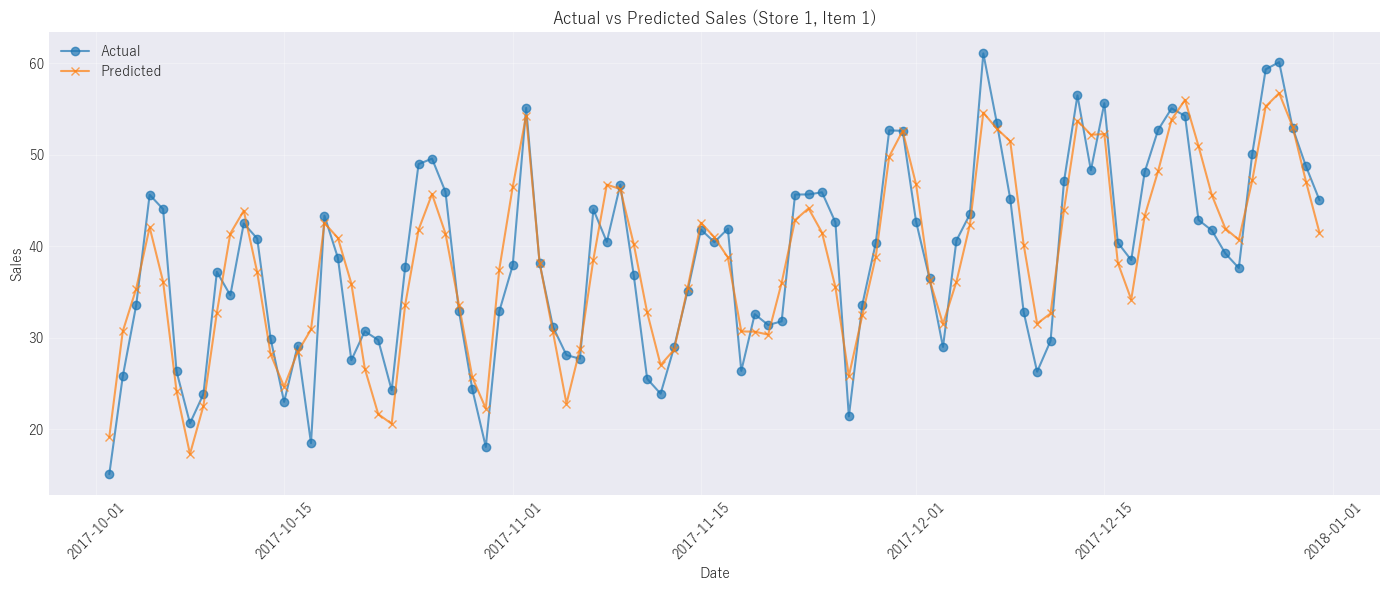

In [16]:
# 1つの店舗・商品の予測を可視化
sample_mask = (train_sorted['store'] == 1) & (train_sorted['item'] == 1)
sample_val_mask = sample_mask & val_mask

if sample_val_mask.sum() > 0:
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # 実測値
    dates_val = train_sorted.loc[sample_val_mask, 'date']
    actual_val = y_val[sample_val_mask.values[val_mask]]
    predicted_val = ensemble_preds[sample_val_mask.values[val_mask]]
    
    ax.plot(dates_val, actual_val, label='Actual', marker='o', alpha=0.7)
    ax.plot(dates_val, predicted_val, label='Predicted', marker='x', alpha=0.7)
    ax.set_title('Actual vs Predicted Sales (Store 1, Item 1)')
    ax.set_xlabel('Date')
    ax.set_ylabel('Sales')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 🎓 7. まとめ

### 🎯 このノートブックで学んだこと

**時系列の基礎**
- ✓ 時系列の3成分（トレンド、季節性、残差）
- ✓ ACF/PACFによる自己相関分析
- ✓ 時系列予測が通常の機械学習と異なる理由

**特徴量エンジニアリング**
- ✓ 周期性の正弦・余弦エンコーディング
- ✓ Lag特徴量（過去の値を特徴量化）
- ✓ Rolling特徴量（移動平均、移動標準偏差）

**モデリングと評価**
- ✓ 時系列分割（Temporal Split）の重要性
- ✓ GBDTによる時系列予測
- ✓ SMAPEによる評価

---

### 📊 時系列予測のチートシート

| ステップ | 手法 | コード例 |
|----------|------|----------|
| 日付特徴量 | 曜日、月など | `df['dayofweek'] = df['date'].dt.dayofweek` |
| 周期性エンコード | sin/cos変換 | `np.sin(2 * np.pi * month / 12)` |
| Lag特徴量 | shift | `df.groupby('id')['y'].shift(7)` |
| Rolling特徴量 | rolling | `df.groupby('id')['y'].transform(lambda x: x.rolling(7).mean())` |
| 時系列分割 | 時間順 | `train = df[df['date'] < split_date]` |
| 評価 | SMAPE | `100 * mean(abs(y - pred) / ((abs(y) + abs(pred)) / 2))` |

### 🔧 実践的なワークフロー

```python
# 1. 日付特徴量
df['dayofweek'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)

# 2. Lag特徴量（グループごと）
for lag in [1, 7, 14, 28]:
    df[f'lag_{lag}'] = df.groupby(['store', 'item'])['sales'].shift(lag)

# 3. Rolling特徴量
for window in [7, 14, 30]:
    df[f'rolling_mean_{window}'] = (
        df.groupby(['store', 'item'])['sales']
        .transform(lambda x: x.rolling(window).mean())
    )

# 4. 時系列分割（シャッフルなし！）
split_date = df['date'].max() - pd.Timedelta(days=90)
train = df[df['date'] < split_date]
val = df[df['date'] >= split_date]

# 5. モデル学習と予測
model.fit(X_train, y_train)
pred = np.maximum(0, model.predict(X_val))  # 負の値をクリップ
```

---

## ⚠️ よくあるエラーと解決法

### ⚠️ エラー #1: 予測精度が異常に高い（データリーク）

**症状:** CVスコアが99%以上など、非現実的に良い

**原因:**
1. 未来の情報を特徴量として使っている
2. データをシャッフルしてからCV

**✅ 解決法:**

```python
# ❌ 問題のあるコード: shiftの方向が逆
df['future_sales'] = df['sales'].shift(-1)  # 未来の売上！

# ✅ 正しいコード: 過去の情報のみ使用
df['lag_1'] = df['sales'].shift(1)  # 過去の売上

# ❌ 問題のあるコード: ランダムにシャッフル
from sklearn.model_selection import KFold
cv = KFold(n_splits=5, shuffle=True)  # NG！

# ✅ 正しいコード: 時系列CV
from sklearn.model_selection import TimeSeriesSplit
cv = TimeSeriesSplit(n_splits=5)  # OK
```

---

### ⚠️ エラー #2: Lag特徴量で欠損値が発生

**症状:** 最初のN行がNaN

```
lag_7を作ると、最初の7行はNaN（7日前のデータがない）
```

**✅ 解決法:**

```python
# 方法1: NaNを削除（データが減る）
df = df.dropna()

# 方法2: 0で補完（GBDTは欠損を扱える場合もある）
df = df.fillna(0)

# 方法3: 特定の値で補完
df['lag_7'] = df['lag_7'].fillna(df['sales'].mean())

# 方法4: groupbyでの補完
df['lag_7'] = df.groupby(['store', 'item'])['lag_7'].transform(
    lambda x: x.fillna(x.mean())
)
```

---

### ⚠️ エラー #3: 予測値が負になる

**原因:** 回帰モデルは制約なしに負の値を予測できる

**✅ 解決法:**

```python
# 予測後にクリップ
predictions = model.predict(X_test)
predictions = np.maximum(0, predictions)  # 負を0に

# または、対数変換して学習
y_train_log = np.log1p(y_train)
model.fit(X_train, y_train_log)
predictions = np.expm1(model.predict(X_test))  # 常に正
```

---

## 🎓 自己評価クイズ

学習内容を確認しましょう！

### Q1: 時系列データでランダムシャッフルしてはいけない理由は？

<details>
<summary>💡 答えを見る</summary>

**答え**: 未来のデータで学習して過去を予測するという、現実にはありえない状況（データリーク）が発生するから。

**詳細:**
- シャッフルすると、時間の順序が壊れる
- 「12月のデータで学習 → 1月を予測」が起こりうる
- CVスコアは良くなるが、実際の予測では使えないモデルになる

</details>

---

### Q2: Lag特徴量とRolling特徴量の違いは？

<details>
<summary>💡 答えを見る</summary>

**答え**: 
- **Lag特徴量**: 特定の時点の過去の値（例：7日前の売上）
- **Rolling特徴量**: 過去N日間の統計量（例：過去7日間の平均売上）

**使い分け:**
- Lag: 特定の周期パターンを捉える（週次なら7日前）
- Rolling: ノイズを平滑化し、トレンドを捉える

</details>

---

### Q3: SMAPEがMAPEより優れている点は？

<details>
<summary>💡 答えを見る</summary>

**答え**: SMAPEは過大予測と過小予測を対称に扱う。

**例:**
- 実測10、予測5の場合：MAPE=50%、SMAPE=66.7%
- 実測5、予測10の場合：MAPE=100%、SMAPE=66.7%

MAPEは過小予測（予測が小さすぎ）を重く罰するが、SMAPEは両方を公平に扱う。

</details>

---

### Q4: 正弦・余弦エンコーディングを使う理由は？

<details>
<summary>💡 答えを見る</summary>

**答え**: 周期的な特徴量（月、曜日など）において、端の値（例：12月と1月）が「近い」ことをモデルに伝えるため。

**例（月）:**
- 通常のエンコード: 1月=1, 12月=12 → 距離=11（遠い）
- sin/cos: 1月と12月の角度は近い → 距離が小さい（近い）

</details>

---

### Q5: 予測時にlag_1が使えない場合の対処法は？

<details>
<summary>💡 答えを見る</summary>

**答え**: 
1. **再帰的予測**: 前の予測値をlag_1として使用（誤差が累積するリスク）
2. **直接予測**: lag_1を使わず、lag_7以上のみ使用（精度低下のリスク）
3. **ハイブリッド**: 短期予測では再帰的、長期予測では直接

**実務的には**:
- 予測期間が短い（1-2日）なら再帰的
- 予測期間が長い（30日以上）なら直接予測が安定

</details>

---

## 📚 練習問題

### 練習1: 異なるLagの比較
lag_1, lag_7, lag_14, lag_28のみを使った4つのモデルを作成し、特徴量重要度を比較してください。

### 練習2: Walk-Forward CVの実装
TimeSeriesSplitを使って5-Fold Walk-Forward CVを実装し、各フォールドのスコアを表示してください。

### 練習3: 祝日特徴量の追加
日本の祝日データを追加し、祝日フラグがモデルの精度にどう影響するか調べてください。

---

### ✅ 学習チェックリスト

- [ ] 時系列の3成分を説明できる
- [ ] ACF/PACFグラフを解釈できる
- [ ] Lag特徴量とRolling特徴量を正しく作成できる
- [ ] 時系列データを正しく分割できる（シャッフルしない）
- [ ] SMAPEの計算方法を理解している

---

## ➡️ 次のステップ

### 学習を続ける

次は **Notebook 20: Optuna自動ハイパーパラメータ最適化** へ進みましょう！

ベイズ最適化の原理を学び、GBDTのハイパーパラメータを効率的に探索する方法をマスターします。

### 復習が必要な場合

- **Notebook 18**: 回帰問題の基礎（対数変換、残差分析）
- **Notebook 13-14**: GBDTの基礎

### さらに学ぶために

**推奨リソース:**
- 書籍: "Forecasting: Principles and Practice" (無料オンライン)
- Kaggle Learn: "Time Series"
- statsmodels公式ドキュメント

---

**⏰ Happy Forecasting! 🎉**